In [17]:
!pip install -q timm albumentations grad-cam opencv-python-headless

In [18]:
import torch

print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"CUDA available: {torch.cuda.is_available()}")

GPU: Tesla T4
CUDA available: True


In [19]:
import kagglehub

# Download competition dataset
path = kagglehub.competition_download("aptos2019-blindness-detection")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/competitions/aptos2019-blindness-detection


In [20]:
import os

DATA_DIR = "/kaggle/input/competitions/aptos2019-blindness-detection"
print(os.listdir(DATA_DIR))

['sample_submission.csv', 'train_images', 'train.csv', 'test.csv', 'test_images']


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
from pathlib import Path
from PIL import Image
import warnings
warnings.filterwarnings("ignore")

plt.style.use("dark_background")

TRAIN_CSV = Path(DATA_DIR) / "train.csv"
TRAIN_IMGS = Path(DATA_DIR) / "train_images"

CLASS_NAMES = {
    0: "No DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferative DR"
}

COLORS = ['#5DCAA5', '#FAC775', '#F0997B', '#D85A30', '#993C1D']

In [22]:
df = pd.read_csv(TRAIN_CSV)

print(f"Total Samples: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nClass Distribution: {df['diagnosis'].value_counts().sort_index()}")
print(f"\nNull Values: {df.isnull().sum().sum()}")

Total Samples: 3662
Columns: ['id_code', 'diagnosis']

Class Distribution: diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64

Null Values: 0


## **Class Distribution Plot**

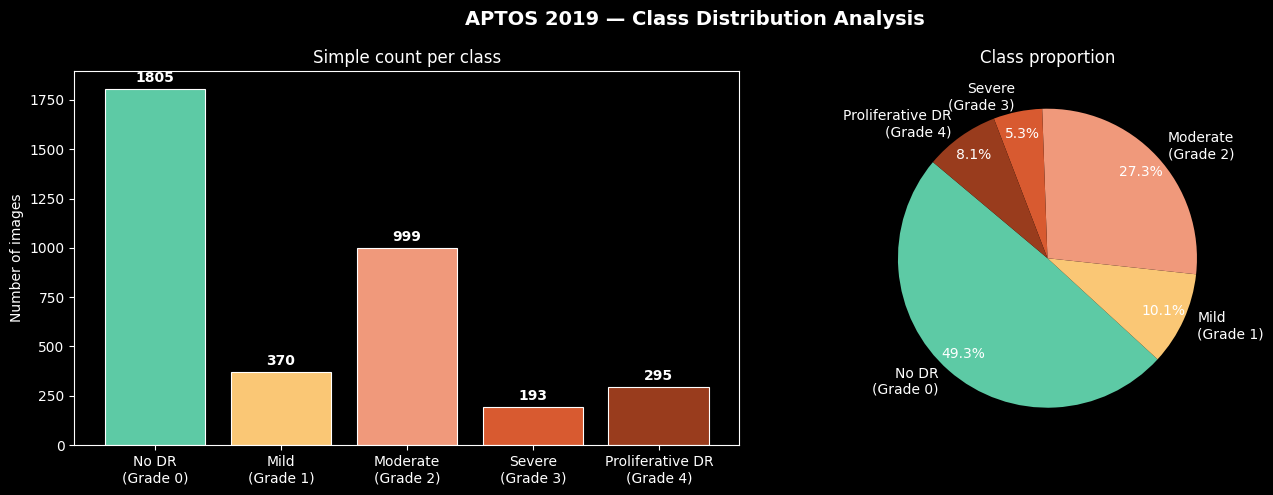


IMBALANCE RATIO: 9.4x


In [23]:
fig, axes = plt.subplots(1, 2, figsize = (14, 5))
fig.suptitle("APTOS 2019 — Class Distribution Analysis", fontsize = 14, fontweight = "bold")

counts = df['diagnosis'].value_counts().sort_index()
labels = [f"{CLASS_NAMES[i]}\n(Grade {i})" for i in counts.index]


# Bar Chart
bars = axes[0].bar(labels, counts.values, color = COLORS, edgecolor = 'white', linewidth = 0.8)
axes[0].set_title("Simple count per class")
axes[0].set_ylabel("Number of images")
for bar, count in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                str(count), ha = "center", va = "bottom", fontsize = 10, fontweight = "bold")

# Pie Chart
axes[1].pie(counts.values, labels = labels, colors = COLORS, autopct = "%1.1f%%",
           startangle = 140, pctdistance = 0.85)
axes[1].set_title("Class proportion")


plt.tight_layout()
plt.savefig("class_distribution.png", dpi = 150, bbox_inches = "tight")
plt.show()


majority = counts.max()
minority = counts.min()
print(f"\nIMBALANCE RATIO: {majority / minority:.1f}x")

=== Image Size Statistics ===
       height   width  megapixels
count   500.0   500.0       500.0
mean   1540.7  2037.4         3.6
std     559.3   917.7         2.7
min     358.0   474.0         0.2
25%    1050.0  1050.0         1.1
50%    1536.0  2144.0         3.2
75%    1958.0  2588.0         5.1
max    2848.0  4288.0        12.2


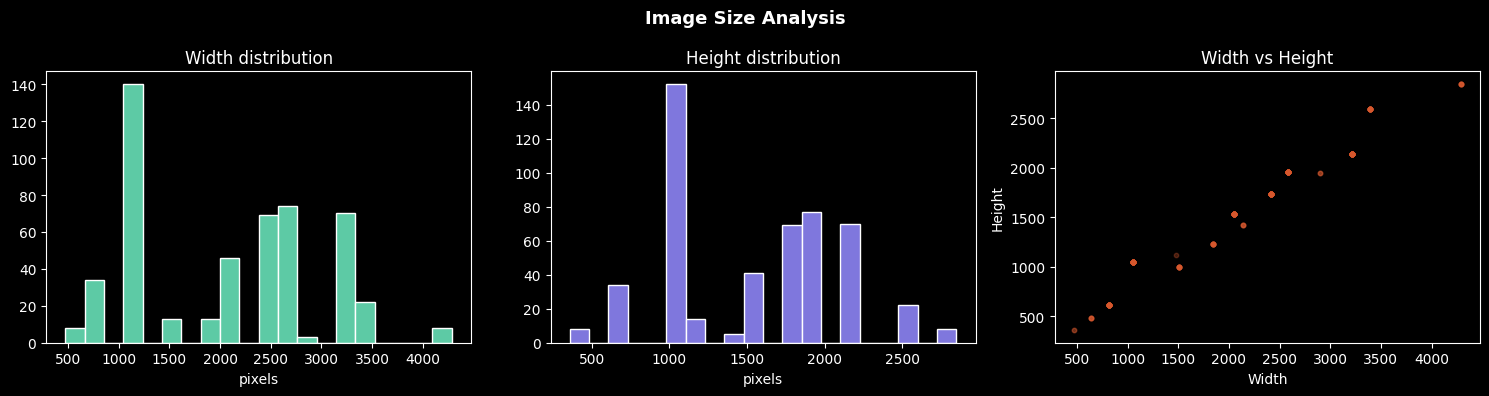

In [ ]:
sample_sizes = []

for img_name in df['id_code'].sample(500, random_state = 42):
    img_path = TRAIN_IMGS / f"{img_name}.png"
    if img_path.exists():
        img = cv2.imread(str(img_path))
        if img is not None:
            h, w = img.shape[:2]
            sample_sizes.append(
                {
                    "name": img_name,
                    "height": h,
                    "width": w,
                    "ratio": w/h,
                    "megapixels": round(h*w / 1e6, 2)
                }
            )

size_df = pd.DataFrame(sample_sizes)
print(f"=== Image Size Statistics ===")
print(size_df[['height', 'width', 'megapixels']].describe().round(1))

fig, axes = plt.subplots(1, 3, figsize = (15, 4))
axes[0].hist(size_df['width'],  bins = 20, color = '#5DCAA5', edgecolor = 'white')
axes[0].set_title("Width distribution");  axes[0].set_xlabel("pixels")
axes[1].hist(size_df['height'], bins = 20, color = '#7F77DD', edgecolor = 'white')
axes[1].set_title("Height distribution"); axes[1].set_xlabel("pixels")
axes[2].scatter(size_df['width'], size_df['height'], alpha = 0.3, color = '#D85A30', s = 10)
axes[2].set_title("Width vs Height"); axes[2].set_xlabel("Width"); axes[2].set_ylabel("Height")
plt.suptitle("Image Size Analysis", fontsize = 13, fontweight = 'bold')
plt.tight_layout()
plt.show()

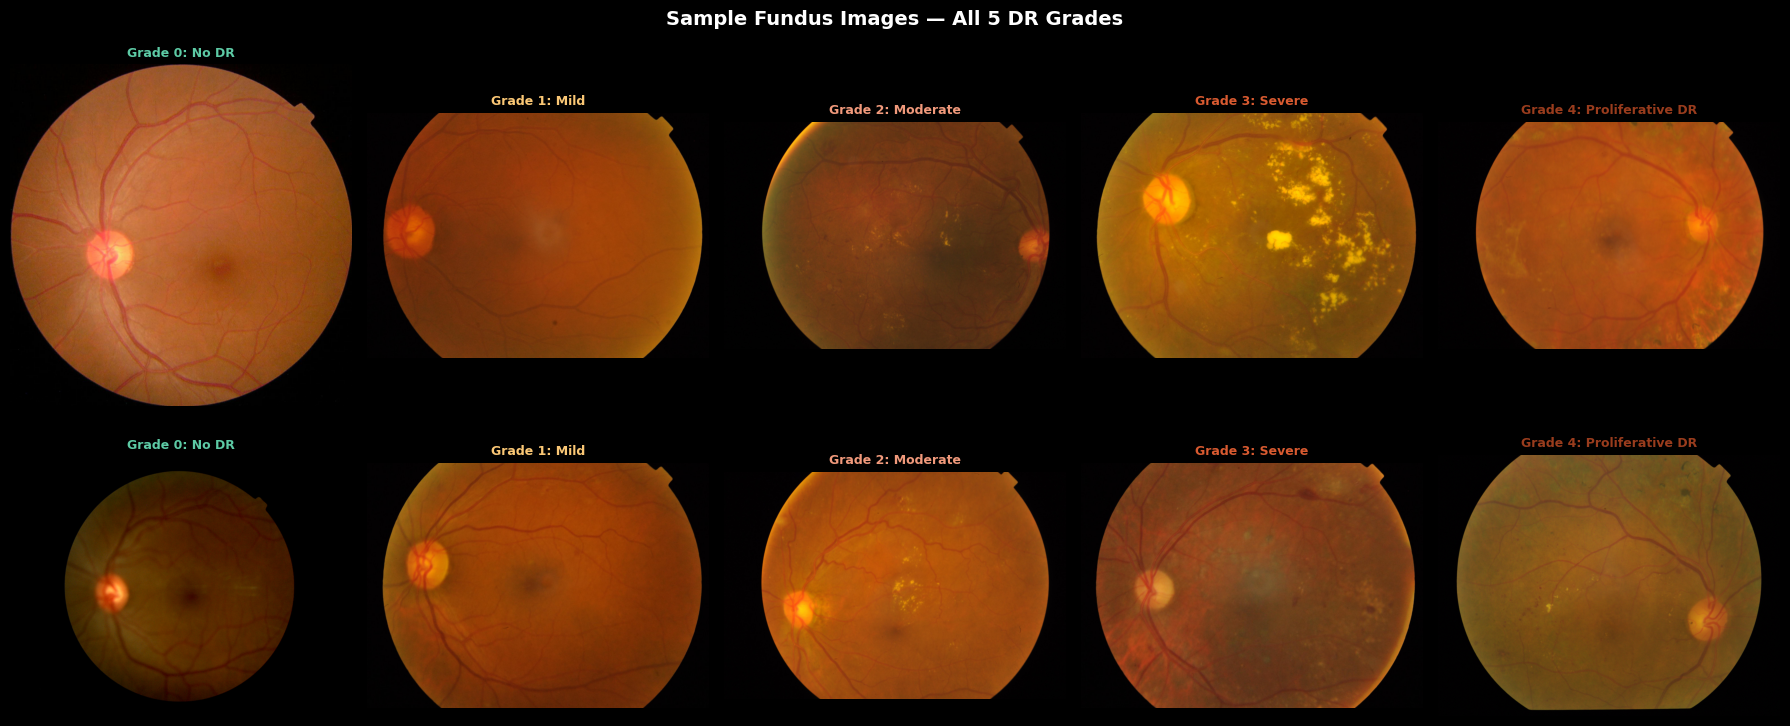

In [25]:
fig, axes = plt.subplots(2, 5, figsize = (18, 8))
fig.suptitle("Sample Fundus Images — All 5 DR Grades", fontsize = 14, fontweight = 'bold')

for grade in range(5):
    grade_imgs = df[df['diagnosis'] == grade]['id_code'].values
    
    # Show 2 samples per grade
    for row_idx in range(2):
        idx = row_idx * 5 + grade
        ax = axes[row_idx][grade]
        img_name = grade_imgs[row_idx]
        img_path = TRAIN_IMGS / f"{img_name}.png"
        img = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        ax.set_title(f"Grade {grade}: {CLASS_NAMES[grade]}", 
                     fontsize = 9, color = COLORS[grade], fontweight = 'bold')
        ax.axis('off')

plt.tight_layout()
plt.savefig("sample_images.png", dpi = 150, bbox_inches = 'tight')
plt.show()

Analyzing image quality (sampling 300 images)


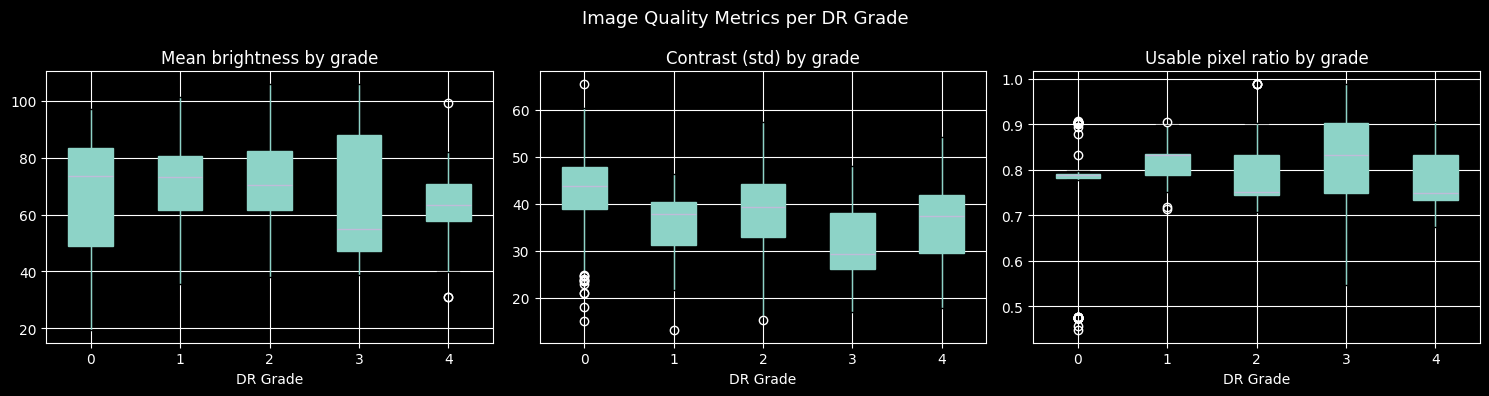


Potentially unusable images: 0 / 300


In [28]:
def analyze_image_quality(img_path):
    img = cv2.imread(str(img_path))
    if img is None:
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Check if iamge is mostly black (bad quality fundus)
    non_black_ratio = np.sum(gray > 20) / gray.size
    return {
        "brightness":       float(gray.mean()),
        "contrast":         float(gray.std()),
        "non_black_ratio":  float(non_black_ratio),
        "is_usable":        non_black_ratio > 0.1
    }


print("Analyzing image quality (sampling 300 images)")
quality_records = []
sample_df = df.sample(300, random_state = 42)

for _, row in sample_df.iterrows():
    img_path = TRAIN_IMGS / f"{row['id_code']}.png"
    q = analyze_image_quality(img_path)
    if q:
        q['diagnosis'] = row['diagnosis']
        quality_records.append(q)

quality_df = pd.DataFrame(quality_records)

fig, axes = plt.subplots(1, 3, figsize = (15, 4))
for i, (metric, title) in enumerate([
    ('brightness', 'Mean brightness by grade'),
    ('contrast',   'Contrast (std) by grade'),
    ('non_black_ratio', 'Usable pixel ratio by grade')
]):
    quality_df.boxplot(column = metric, by = 'diagnosis', ax = axes[i], patch_artist = True)
    axes[i].set_title(title)
    axes[i].set_xlabel("DR Grade")

plt.suptitle("Image Quality Metrics per DR Grade", fontsize = 13)
plt.tight_layout()
plt.show()

unusable = quality_df[~quality_df['is_usable']]
print(f"\nPotentially unusable images: {len(unusable)} / {len(quality_df)}")

In [29]:
def get_channel_stats(img_path):
    img = cv2.imread(str(img_path))
    if img is None: return None
    b, g, r = cv2.split(img)
    return {
        "r_mean": r.mean(),
        "g_mean": g.mean(),
        "b_mean": b.mean()
    }

channel_records = []

for _, row in df.sample(200, random_state = 0).iterrows():
    img_path = TRAIN_IMGS / f"{row['id_code']}.png"
    stats = get_channel_stats(img_path)
    if stats:
        stats['diagnosis'] = row['diagnosis']
        channel_records.append(stats)

ch_df = pd.DataFrame(channel_records)
print("=== Mean channel values per DR grade ===")
print(ch_df.groupby('diagnosis')[['r_mean', 'g_mean', 'b_mean']].mean().round(2))
print("\nObservation: Green channel is most informative for retinal vessels")

=== Mean channel values per DR grade ===
           r_mean  g_mean  b_mean
diagnosis                        
0           98.00   54.01   17.35
1          116.35   57.02   16.61
2          111.12   62.17   24.20
3          109.53   58.26   23.28
4          112.24   62.20   22.25

Observation: Green channel is most informative for retinal vessels


In [30]:
print("=" * 60)
print("EDA COMPLETE — KEY FINDINGS & DECISIONS")
print("=" * 60)

counts = df['diagnosis'].value_counts().sort_index()
print(f"\n1. DATASET SIZE:     {len(df)} images, 5 classes")
print(f"2. IMBALANCE RATIO:  {counts.max()/counts.min():.1f}x (Grade 0 >> Grade 1)")
print(f"3. IMAGE SIZES:      Variable (512px to 3000px+) → resize to 512x512")
print(f"4. INPUT SIZE:       EfficientNet-B4 → 380x380, ViT → 384x384")
print(f"5. PREPROCESSING:    Ben Graham + CLAHE on green channel")
print(f"6. AUGMENTATION:     Heavy (rotation, flip, brightness, coarse dropout)")
print(f"7. LOSS FUNCTION:    Weighted CrossEntropy OR Smooth L1 (regression head)")
print(f"8. METRIC:           Quadratic Weighted Kappa (QWK) — competition standard")
print(f"9. TRAIN/VAL SPLIT:  80/20, stratified by class")
print(f"10. NEXT STEP:       Phase 2 — Ben Graham preprocessing pipeline")
print("=" * 60)

EDA COMPLETE — KEY FINDINGS & DECISIONS

1. DATASET SIZE:     3662 images, 5 classes
2. IMBALANCE RATIO:  9.4x (Grade 0 >> Grade 1)
3. IMAGE SIZES:      Variable (512px to 3000px+) → resize to 512x512
4. INPUT SIZE:       EfficientNet-B4 → 380x380, ViT → 384x384
5. PREPROCESSING:    Ben Graham + CLAHE on green channel
6. AUGMENTATION:     Heavy (rotation, flip, brightness, coarse dropout)
7. LOSS FUNCTION:    Weighted CrossEntropy OR Smooth L1 (regression head)
8. METRIC:           Quadratic Weighted Kappa (QWK) — competition standard
9. TRAIN/VAL SPLIT:  80/20, stratified by class
10. NEXT STEP:       Phase 2 — Ben Graham preprocessing pipeline
